## Improved Moving Baseball Detection Model

This notebook presents an improved Faster R-CNN model for detecting moving baseballs. It serves as a robustness check against the baseline model by incorporating refined data processing and visualization techniques. The goal is to evaluate whether these improvements enhance detection performance on unseen data.

## Notebook Workflow

#### 1. Mount Google Drive and Setup
#### 2. Import Libraries and Define Project Paths
#### 3. Load and Verify Data (Video–Annotation Matching)
#### 4. Extract Frames from Videos
#### 5. Process Annotations (Including Moving Attribute)
#### 6. Filter for Moving Baseballs
#### 7. Build Dataset (Positive and Negative Samples)
#### 8. Train–Validation Split (By Video)
#### 9. DataLoader Setup
#### 10. Model Setup (Faster R-CNN)
#### 11. Model Training
#### 12. Model Evaluation and Prediction
#### 13. Visualization of Results (Full Image + Zoomed)

In [ ]:
# Setup: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Setup: Import Libraries and Define Project Paths

from pathlib import Path
import cv2
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Correct path (matches your actual folder)
PROJECT_DIR = Path("/content/drive/MyDrive/baseball-final-project")

VIDEOS_DIR = PROJECT_DIR / "videos_final"
ANNOTATIONS_DIR = PROJECT_DIR / "annotations_final"
FRAMES_DIR = PROJECT_DIR / "frames"

# Create frames folder
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

# Check files
video_files = list(VIDEOS_DIR.glob("*.mov")) + list(VIDEOS_DIR.glob("*.MOV"))
annotation_files = list(ANNOTATIONS_DIR.glob("*.xml"))

print("Videos folder exists:", VIDEOS_DIR.exists())
print("Annotations folder exists:", ANNOTATIONS_DIR.exists())
print("Videos found:", len(video_files))
print("XML files found:", len(annotation_files))

Videos folder exists: True
Annotations folder exists: True
Videos found: 64
XML files found: 64


In [ ]:

# Data Check: Verify Video and Annotation Files Match

# Collect all video and annotation files
video_files = sorted(VIDEOS_DIR.glob("*.mov"))
annotation_files = sorted(ANNOTATIONS_DIR.glob("*.xml"))

# Compare file names without extensions
video_names = {file.stem for file in video_files}
annotation_names = {file.stem for file in annotation_files}

missing_annotations = sorted(video_names - annotation_names)
extra_annotations = sorted(annotation_names - video_names)

print("Number of videos:", len(video_files))
print("Number of annotations:", len(annotation_files))
print("Missing annotations:", missing_annotations)
print("Extra annotations:", extra_annotations)

Number of videos: 64
Number of annotations: 64
Missing annotations: []
Extra annotations: []


In [4]:
# Extract ONLY annotated frames from videos

def extract_annotated_frames(video_path, xml_path, output_dir):
    cap = cv2.VideoCapture(str(video_path))
    video_name = video_path.stem

    # Create output folder
    video_out_dir = output_dir / video_name
    video_out_dir.mkdir(parents=True, exist_ok=True)

    # Parse XML to get annotated frame indices
    tree = ET.parse(xml_path)
    root = tree.getroot()

    annotated_frames = set()

    for track in root.findall("track"):
        for box in track.findall("box"):
            if box.attrib.get("outside") == "1":
                continue
            annotated_frames.add(int(box.attrib["frame"]))

    frame_idx = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx in annotated_frames:
            frame_file = video_out_dir / f"{video_name}_frame_{frame_idx:04d}.jpg"
            cv2.imwrite(str(frame_file), frame)
            saved_count += 1

        frame_idx += 1

    cap.release()
    print(f"{video_name}: saved {saved_count} annotated frames")


# Run extraction for all videos
for video_path in video_files:
    xml_path = ANNOTATIONS_DIR / f"{video_path.stem}.xml"
    extract_annotated_frames(video_path, xml_path, FRAMES_DIR)

IMG_0030: saved 3 annotated frames
IMG_0031: saved 3 annotated frames
IMG_0032: saved 3 annotated frames
IMG_0033: saved 3 annotated frames
IMG_0034: saved 3 annotated frames
IMG_0035: saved 2 annotated frames
IMG_0036: saved 2 annotated frames
IMG_0037: saved 2 annotated frames
IMG_0038: saved 3 annotated frames
IMG_0039: saved 3 annotated frames
IMG_0040: saved 57 annotated frames
IMG_0041: saved 50 annotated frames
IMG_0042: saved 52 annotated frames
IMG_0043: saved 48 annotated frames
IMG_0044: saved 56 annotated frames
IMG_0045: saved 60 annotated frames
IMG_0046: saved 54 annotated frames
IMG_0047: saved 48 annotated frames
IMG_0074: saved 100 annotated frames
IMG_0075: saved 80 annotated frames
IMG_0076: saved 59 annotated frames
IMG_0077: saved 92 annotated frames
IMG_0078: saved 94 annotated frames
IMG_0079: saved 80 annotated frames
IMG_0083: saved 57 annotated frames
IMG_0084: saved 62 annotated frames
IMG_0085: saved 42 annotated frames
IMG_0170: saved 72 annotated frames
I

In [5]:
# Parse CVAT XML annotations into a clean dataframe

all_rows = []
parse_status = {"moving_true": 0, "moving_false": 0, "no_attribute": 0}

for xml_file in annotation_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    video_name = xml_file.stem  # important for matching frames later

    for track in root.findall("track"):
        label = track.attrib.get("label", "unknown")
        track_id = int(track.attrib.get("id", -1))

        for box in track.findall("box"):
            # Skip frames where object is outside
            if box.attrib.get("outside") == "1":
                continue

            frame = int(box.attrib["frame"])

            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])

            occluded = int(box.attrib.get("occluded", 0))

            # Handle "moving" attribute safely
            is_moving = False
            found_moving_attr = False

            for attr in box.findall("attribute"):
                if attr.attrib.get("name", "").strip().lower() == "moving":
                    found_moving_attr = True
                    value = (attr.text or "").strip().lower()
                    is_moving = value in ("true", "1", "yes")
                    break

            if not found_moving_attr:
                parse_status["no_attribute"] += 1
            elif is_moving:
                parse_status["moving_true"] += 1
            else:
                parse_status["moving_false"] += 1

            # Add row
            all_rows.append({
                "video_name": video_name,
                "frame": frame,
                "xtl": xtl,
                "ytl": ytl,
                "xbr": xbr,
                "ybr": ybr,
                "width": xbr - xtl,
                "height": ybr - ytl,
                "area": (xbr - xtl) * (ybr - ytl),
                "occluded": occluded,
                "moving": is_moving
            })

# Convert to DataFrame
annotations_df = pd.DataFrame(all_rows)

# Sort for consistency
annotations_df = annotations_df.sort_values(["video_name", "frame"]).reset_index(drop=True)

# Output summary
print("Total annotation rows:", len(annotations_df))
print(f"Moving=True: {parse_status['moving_true']}")
print(f"Moving=False: {parse_status['moving_false']}")
print(f"No 'moving' attribute: {parse_status['no_attribute']}")

annotations_df.head()

Total annotation rows: 24361
Moving=True: 1479
Moving=False: 22807
No 'moving' attribute: 75


,video_name,frame,xtl,ytl,xbr,ybr,width,height,area,occluded,moving
0,IMG_0030,25,2100.1,1649.50,2160.00,1740.60,59.90,91.10,5456.890,0,True
1,IMG_0030,26,1512.0,1763.00,1734.00,1875.70,222.00,112.70,25019.400,0,True
2,IMG_0030,27,1730.6,1880.10,1931.34,1965.65,200.74,85.55,17173.307,0,True
3,IMG_0031,25,1854.0,1501.50,2076.20,1616.20,222.20,114.70,25486.340,0,True
4,IMG_0031,26,1273.8,1628.25,1488.50,1739.70,214.70,111.45,23928.315,0,True


In [6]:
# Create image paths and filter for moving baseball annotations

# Create expected image filename for each annotated frame
annotations_df["image_file"] = (
    annotations_df["video_name"]
    + "_frame_"
    + annotations_df["frame"].astype(str).str.zfill(4)
    + ".jpg"
)

# Create full image path
annotations_df["image_path"] = annotations_df.apply(
    lambda row: FRAMES_DIR / row["video_name"] / row["image_file"],
    axis=1
)

# Confirm that image files exist
annotations_df["image_exists"] = annotations_df["image_path"].apply(lambda path: path.exists())

print("Total annotation rows:", len(annotations_df))
print("Rows with existing images:", annotations_df["image_exists"].sum())
print("Missing images:", len(annotations_df) - annotations_df["image_exists"].sum())

# Keep only rows with valid images
annotations_df = annotations_df[annotations_df["image_exists"]].reset_index(drop=True)

# Main project focus: moving baseball only
moving_annotations_df = annotations_df[annotations_df["moving"] == True].reset_index(drop=True)

print("Moving baseball rows:", len(moving_annotations_df))

moving_annotations_df[["video_name", "frame", "image_file", "image_exists", "moving"]].head()

Total annotation rows: 24361
Rows with existing images: 24361
Missing images: 0
Moving baseball rows: 1479


,video_name,frame,image_file,image_exists,moving
0,IMG_0030,25,IMG_0030_frame_0025.jpg,True,True
1,IMG_0030,26,IMG_0030_frame_0026.jpg,True,True
2,IMG_0030,27,IMG_0030_frame_0027.jpg,True,True
3,IMG_0031,25,IMG_0031_frame_0025.jpg,True,True
4,IMG_0031,26,IMG_0031_frame_0026.jpg,True,True


In [7]:
# Build dataset for moving baseball detection (clean version)

# Use moving baseball annotations
moving_df = moving_annotations_df.copy()

print("Annotation rows after filtering for moving:", len(moving_df))

# All annotated frames (for negatives too)
all_frames = annotations_df[["image_path", "video_name"]].drop_duplicates()

# Group moving annotations by image
moving_grouped = moving_df.groupby("image_path")

dataset = []

for _, row in all_frames.iterrows():
    image_path = row["image_path"]

    if image_path in moving_grouped.groups.keys():
        group = moving_grouped.get_group(image_path)
        boxes = group[["xtl", "ytl", "xbr", "ybr"]].values.tolist()
        labels = [1] * len(boxes)  # 1 = moving baseball
    else:
        # Negative sample (no moving baseball)
        boxes = []
        labels = []

    dataset.append({
        "image_path": image_path,
        "boxes": boxes,
        "labels": labels
    })

# Summary stats
n_positive = sum(1 for item in dataset if len(item["boxes"]) > 0)
n_negative = sum(1 for item in dataset if len(item["boxes"]) == 0)

print(f"Total images: {len(dataset)}")
print(f"With moving baseballs (positive): {n_positive}")
print(f"Without moving baseballs (negative): {n_negative}")

Annotation rows after filtering for moving: 1479
Total images: 2820
With moving baseballs (positive): 1189
Without moving baseballs (negative): 1631


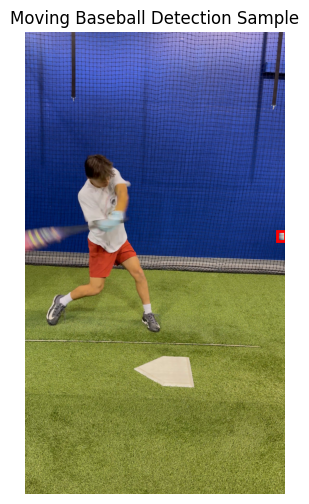

In [8]:
# Visualize a positive (moving baseball) sample

import matplotlib.patches as patches

# Find a positive sample
positive_sample = None
for item in dataset:
    if len(item["boxes"]) > 0:
        positive_sample = item
        break

# Load image
image = Image.open(positive_sample["image_path"])

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(image)

# Draw bounding boxes
for box in positive_sample["boxes"]:
    xtl, ytl, xbr, ybr = box
    width = xbr - xtl
    height = ybr - ytl

    rect = patches.Rectangle(
        (xtl, ytl),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

ax.set_title("Moving Baseball Detection Sample")
ax.axis("off")
plt.show()

In [9]:
# Split dataset by video to prevent leakage between training and validation

from sklearn.model_selection import train_test_split

# Split dataset by video to prevent leakage
all_videos = sorted(all_frames["video_name"].unique())

train_videos, val_videos = train_test_split(
    all_videos,
    test_size=0.2,
    random_state=42
)

train_videos = set(train_videos)
val_videos = set(val_videos)

# Map image_path → video_name
image_path_to_video_name = all_frames.set_index("image_path")["video_name"].to_dict()

train_data = [
    sample for sample in dataset
    if image_path_to_video_name[sample["image_path"]] in train_videos
]

val_data = [
    sample for sample in dataset
    if image_path_to_video_name[sample["image_path"]] in val_videos
]

# Count positives and negatives
train_positive = sum(1 for sample in train_data if len(sample["boxes"]) > 0)
train_negative = sum(1 for sample in train_data if len(sample["boxes"]) == 0)

val_positive = sum(1 for sample in val_data if len(sample["boxes"]) > 0)
val_negative = sum(1 for sample in val_data if len(sample["boxes"]) == 0)

print("Training videos:", len(train_videos))
print("Validation videos:", len(val_videos))
print("Training images:", len(train_data))
print("Validation images:", len(val_data))

print("Training positive images:", train_positive)
print("Training negative images:", train_negative)
print("Validation positive images:", val_positive)
print("Validation negative images:", val_negative)

Training videos: 51
Validation videos: 13
Training images: 2388
Validation images: 432
Training positive images: 1072
Training negative images: 1316
Validation positive images: 117
Validation negative images: 315


In [10]:
# Sanity check

train_moving_boxes = sum(len(s["boxes"]) for s in train_data)
val_moving_boxes = sum(len(s["boxes"]) for s in val_data)

train_pos_frames = sum(1 for s in train_data if len(s["boxes"]) > 0)
val_pos_frames = sum(1 for s in val_data if len(s["boxes"]) > 0)

print("Train moving boxes:", train_moving_boxes)
print("Val moving boxes:", val_moving_boxes)

print("Train frames with moving baseball:", train_pos_frames)
print("Val frames with moving baseball:", val_pos_frames)

Train moving boxes: 1362
Val moving boxes: 117
Train frames with moving baseball: 1072
Val frames with moving baseball: 117


In [11]:
# Custom PyTorch Dataset for moving baseball object detection

from torchvision.transforms import functional as F

class BaseballDataset(Dataset):
    def __init__(self, data, resize_size=(640, 640)):
        self.data = data
        self.resize_size = resize_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        # Open image and convert to RGB
        image = Image.open(sample["image_path"]).convert("RGB")
        original_width, original_height = image.size

        # Resize image
        new_width, new_height = self.resize_size
        image = image.resize((new_width, new_height))

        # Convert image to tensor
        image = F.to_tensor(image)

        # Handle positive and negative samples
        if len(sample["boxes"]) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(sample["boxes"], dtype=torch.float32)

            # Scale bounding boxes to match resized image
            scale_x = new_width / original_width
            scale_y = new_height / original_height

            boxes[:, [0, 2]] = boxes[:, [0, 2]] * scale_x
            boxes[:, [1, 3]] = boxes[:, [1, 3]] * scale_y

            labels = torch.tensor(sample["labels"], dtype=torch.int64)

        # Extra target fields expected by Faster R-CNN
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
            "area": area,
            "iscrowd": iscrowd
        }

        return image, target


# Create training and validation datasets
train_dataset = BaseballDataset(train_data, resize_size=(640, 640))
val_dataset = BaseballDataset(val_data, resize_size=(640, 640))

# Test one item
image, target = train_dataset[0]

print("Image shape:", image.shape)
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"][:10])
print("Area shape:", target["area"].shape)
print("Is crowd shape:", target["iscrowd"].shape)

Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([1, 4])
Labels: tensor([1])
Area shape: torch.Size([1])
Is crowd shape: torch.Size([1])


In [12]:
# Custom collate function because each image may have a different number of bounding boxes

def collate_fn(batch):
    return tuple(zip(*batch))


# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# Test one batch
images, targets = next(iter(train_loader))

print("Number of images in batch:", len(images))
print("Image shape:", images[0].shape)
print("Boxes shape:", targets[0]["boxes"].shape)
print("Labels:", targets[0]["labels"][:10])

Number of images in batch: 2
Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([2, 4])
Labels: tensor([1, 1])


In [13]:
# Use GPU if available; otherwise use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("Using device:", device)


Using device: cuda


In [15]:
# Load a pretrained Faster R-CNN model for object detection
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# The model needs two classes: background and baseball
num_classes = 2

# Replace the classification head so the model predicts baseballs instead of COCO classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to the selected device
model.to(device)

print("Model ready on:", device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 156MB/s]


Model ready on: cuda


In [16]:
# Recreate DataLoader only (dataset already exists)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

print("Training images:", len(train_dataset))

Training images: 2388


In [17]:
# Train Faster R-CNN model for moving baseball detection

# Set up optimizer
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Train for multiple epochs
num_epochs = 4

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [
            {k: v.to(device) for k, v in target.items()}
            for target in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if i % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Step {i}, Loss: {losses.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} complete. Average loss: {avg_loss:.4f}")

print("Training complete.")

Epoch 1/4, Step 0, Loss: 0.3673
Epoch 1/4, Step 50, Loss: 0.7180
Epoch 1/4, Step 100, Loss: 0.2290
Epoch 1/4, Step 150, Loss: 0.1003
Epoch 1/4, Step 200, Loss: 0.0861
Epoch 1/4, Step 250, Loss: 0.0144
Epoch 1/4, Step 300, Loss: 0.0400
Epoch 1/4, Step 350, Loss: 0.0099
Epoch 1/4, Step 400, Loss: 0.0027
Epoch 1/4, Step 450, Loss: 0.0335
Epoch 1/4, Step 500, Loss: 0.1139
Epoch 1/4, Step 550, Loss: 0.0035
Epoch 1/4, Step 600, Loss: 0.0585
Epoch 1/4, Step 650, Loss: 0.1232
Epoch 1/4, Step 700, Loss: 0.3199
Epoch 1/4, Step 750, Loss: 0.3440
Epoch 1/4, Step 800, Loss: 0.0788
Epoch 1/4, Step 850, Loss: 0.0851
Epoch 1/4, Step 900, Loss: 0.2869
Epoch 1/4, Step 950, Loss: 0.2462
Epoch 1/4, Step 1000, Loss: 0.2382
Epoch 1/4, Step 1050, Loss: 0.3218
Epoch 1/4, Step 1100, Loss: 0.0045
Epoch 1/4, Step 1150, Loss: 0.0667
Epoch 1/4 complete. Average loss: 0.1351
Epoch 2/4, Step 0, Loss: 0.1070
Epoch 2/4, Step 50, Loss: 0.0372
Epoch 2/4, Step 100, Loss: 0.0998
Epoch 2/4, Step 150, Loss: 0.0089
Epoch 2/4

Number of predicted boxes: 2
Top scores: tensor([0.9875, 0.0852])


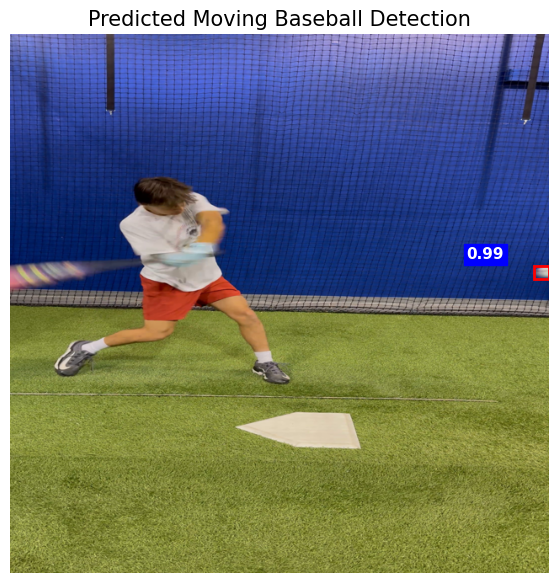

In [22]:
# Visualize predictions on validation image

import matplotlib.patches as patches

model.eval()

test_image, _ = val_dataset[0]

with torch.no_grad():
    prediction = model([test_image.to(device)])

boxes = prediction[0]["boxes"].cpu()
scores = prediction[0]["scores"].cpu()

# Print metrics
print("Number of predicted boxes:", len(boxes))
print("Top scores:", scores[:5])

# Prepare image
image = test_image.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, figsize=(10, 7))
ax.imshow(image)

threshold = 0.5
h, w, _ = image.shape

for box, score in zip(boxes, scores):
    if score >= threshold:
        xtl, ytl, xbr, ybr = box.tolist()

        # ---- THINNER RED BOX ----
        rect = patches.Rectangle(
            (xtl, ytl),
            xbr - xtl,
            ybr - ytl,
            linewidth=2,  # thinner line (was 4 before)
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        # ---- SMART LABEL POSITION ----
        label_x = xtl
        label_y = ytl - 8

        if label_y < 10:
            label_y = ybr + 8

        if xtl > w - 100:
            label_x = xtl - 80

        ax.text(
            label_x,
            label_y,
            f"{score:.2f}",
            color="white",
            fontsize=11,   # slightly smaller for cleaner look
            fontweight="bold",
            bbox=dict(facecolor="blue", edgecolor="blue", pad=2)
        )

ax.set_title("Predicted Moving Baseball Detection", fontsize=15)
ax.axis("off")
plt.show()

Best prediction score: 0.9874621033668518


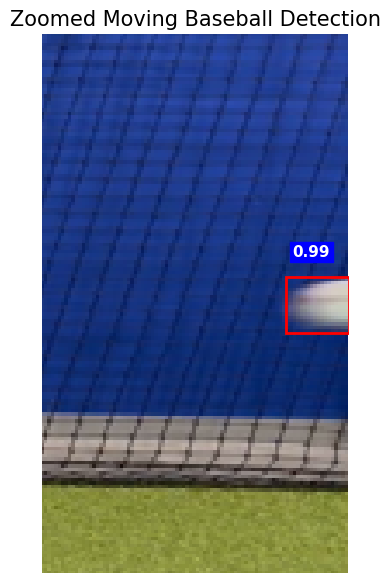

In [23]:
# Zoomed visualization

import matplotlib.patches as patches

model.eval()

test_image, _ = val_dataset[0]

with torch.no_grad():
    prediction = model([test_image.to(device)])

boxes = prediction[0]["boxes"].cpu()
scores = prediction[0]["scores"].cpu()

# Best prediction
best_idx = scores.argmax()
best_box = boxes[best_idx].tolist()
best_score = scores[best_idx].item()

print("Best prediction score:", best_score)

# Prepare image
image = test_image.permute(1, 2, 0).cpu().numpy()
h, w, _ = image.shape

xtl, ytl, xbr, ybr = best_box

# ZOOM REGION
padding = 70

x1 = max(int(xtl - padding), 0)
y1 = max(int(ytl - padding), 0)
x2 = min(int(xbr + padding), w)
y2 = min(int(ybr + padding), h)

fig, ax = plt.subplots(1, figsize=(7, 7))
ax.imshow(image)

# THIN RED BOX
rect = patches.Rectangle(
    (xtl, ytl),
    xbr - xtl,
    ybr - ytl,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)
ax.add_patch(rect)

# TIGHT LABEL POSITION
offset = 6  # small distance from box

label_x = xtl + 2
label_y = ytl - offset

# If too close to top, place below box
if label_y < 10:
    label_y = ybr + offset

ax.text(
    label_x,
    label_y,
    f"{best_score:.2f}",
    color="white",
    fontsize=11,
    fontweight="bold",
    bbox=dict(facecolor="blue", edgecolor="blue", pad=2)
)

# APPLYING ZOOM
ax.set_xlim(x1, x2)
ax.set_ylim(y2, y1)

ax.set_title("Zoomed Moving Baseball Detection", fontsize=15)
ax.axis("off")
plt.show()

In [24]:
# Final evaluation summary (Quick validation check)

model.eval()

all_scores = []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        predictions = model(images)

        for pred in predictions:
            scores = pred["scores"].cpu().numpy()
            all_scores.extend(scores)

print("Total predictions:", len(all_scores))
print("Average confidence score:", np.mean(all_scores))
print("High-confidence detections (>0.5):", np.sum(np.array(all_scores) > 0.5))

Total predictions: 391
Average confidence score: 0.39772278
High-confidence detections (>0.5): 138


In [31]:
# implementing suggestion from other group to use IOU for interpretation
def compute_iou(box1, box2):
  #computing iou between two boxes
  x1 = max(box1[0], box2[0])
  y1 = max(box1[1], box2[1])
  x2 = min(box1[2], box2[2])
  y2 = min(box1[3], box2[3])

  #calculating intersection and union areas
  intersection = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)
  area1 = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
  area2 = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)
  union = area1 + area2 - intersection

  return intersection / union if union > 0 else 0


#for each prediction, we will check how wellit overlaps with the "true" box
model.eval()

iou_threshold = 0.5
score_threshold = 0.5 #only consider high confidence preds


tp, fp, fn = 0,0,0   #true positives, false positives, false negatives
iou_scores = []

with torch.no_grad():
  for images, targets in val_loader:
    images = [img.to(device) for img in images]
    predictions = model(images)

    for pred, target in zip(predictions, targets):
      #filter out low confidence predictions and move to cpu
      keep_pred = pred["scores"] >= score_threshold
      pred_boxes_filtered = pred["boxes"][keep_pred].cpu().tolist()

      gt_boxes = target["boxes"].cpu().tolist()

      # track which ground truth boxes have been matched
      gt_matched_for_image = [False] * len(gt_boxes)

      #for each filtered predicted box
      for pred_box in pred_boxes_filtered:
        max_iou_for_this_pred = 0.0
        best_gt_idx_for_this_pred = -1


        for gt_idx, current_gt_box in enumerate(gt_boxes):
          if not gt_matched_for_image[gt_idx]:
            iou = compute_iou(pred_box, current_gt_box) # Both are now lists of floats
            if iou > max_iou_for_this_pred:
              max_iou_for_this_pred = iou
              best_gt_idx_for_this_pred = gt_idx


        if max_iou_for_this_pred >= iou_threshold and best_gt_idx_for_this_pred != -1:
          tp += 1
          iou_scores.append(max_iou_for_this_pred)
          gt_matched_for_image[best_gt_idx_for_this_pred] = True
        else:
          fp += 1 # This prediction is a false positive

      # count false negatives for the current image
      # these are the truth boxes that were not matched by any prediction
      fn += sum(1 for is_matched in gt_matched_for_image if not is_matched)

# final metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
avg_iou = np.mean(iou_scores) if iou_scores else 0

print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Average IOU: {avg_iou:.3f}")

True positives: 41
False positives: 97
False negatives: 76
Precision: 0.297
Recall: 0.350
F1 score: 0.322
Average IOU: 0.746


In [30]:
# quick final check, are our high confidence predictions actually landing on frames that have a moving baseball?!

model.eval()

correct = 0
total_predictions = 0

#get all image paths that have a moving baseball
moving_image_paths = set(moving_annotations_df["image_path"].astype(str))

with torch.no_grad():
  for images, targets in val_loader:
    images = [img.to(device) for img in images]
    predictions = model(images)

    for i, pred in enumerate(predictions):
      high_conf = pred["scores"] >= 0.5
      if high_conf.sum() == 0:
        continue

      total_predictions += 1

      #get image path validation for this sample
      image_id_in_val_dataset = targets[i]["image_id"].item()
      image_path = str(val_data[image_id_in_val_dataset]["image_path"])

      #check if frame actually contains a moving baseball
      if image_path in moving_image_paths:
        correct += 1

print(f"Correct predictions: {correct}/{total_predictions}")
print(f"Accuracy: {correct / total_predictions:.1%}")

Correct predictions: 78/107
Accuracy: 72.9%
